In [1]:
import copy
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytagi import Normalizer
import pytagi.metric as metric

In [3]:
data_file = "/Users/vuongdai/Desktop/backup_canari/LGA007EFAPRG910.DAT"
df_raw = pd.read_csv(data_file,
                     sep=";",  # Semicolon as delimiter
                     quotechar='"',
                     engine="python",
                     na_values=[""],  # Treat empty strings as NaN
                     skipinitialspace=True,
                     encoding="ISO-8859-1",
                     )

In [4]:
df_raw.head()

,No extensometre,Amenagement,Ouvrage,Unnamed: 3,Date,Nombre Date,Ext/Contraction (mm),Remarque,Niveau reservoir (m),Memo,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,LGA007EFAPRG910,LGA,LGABAR,NaN,2001-09-06 00:00,37140.0,-0.13,NaN,31.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LGA007EFAPRG910,LGA,LGABAR,NaN,2001-09-07 00:00,37141.0,-0.12,NaN,31.33,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LGA007EFAPRG910,LGA,LGABAR,NaN,2001-09-08 00:00,37142.0,-0.13,NaN,31.15,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LGA007EFAPRG910,LGA,LGABAR,NaN,2001-09-09 00:00,37143.0,-0.12,NaN,31.23,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LGA007EFAPRG910,LGA,LGABAR,NaN,2001-09-10 00:00,37144.0,-0.12,NaN,31.22,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df_raw[["Ext/Contraction (mm)"]]
df.columns = ["ext"]
df.index = pd.to_datetime(df_raw["Date"])
# Resampling to weekly
df = df.resample("W").mean()

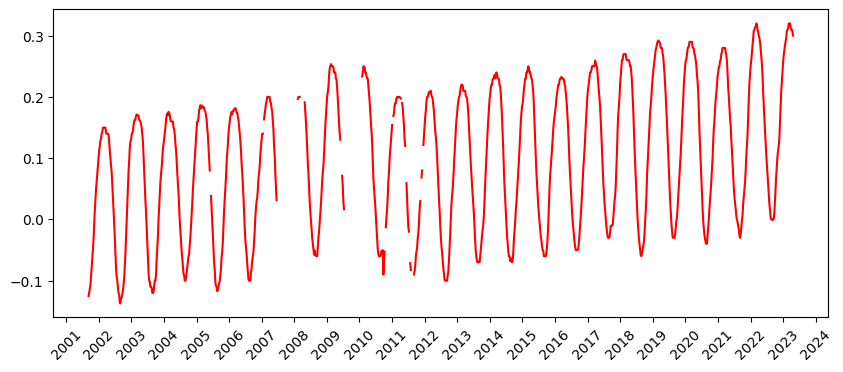

In [12]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(10, 4))
plt.plot(df.index, df["ext"], color="red")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.show()